# Paper Figures — ICML Submission

**Regime-Aware Bayesian Deferral for Seismic Phase Picking Under Distribution Shift**

This notebook generates publication-ready figures from the same data as the main analysis notebook (`Notebook - 3 March.ipynb`). Each figure is formatted for ICML single-column width (3.25 inches) and saved as both PDF (for LaTeX) and PNG (for quick preview) in the `figures/` directory.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Publication rcParams
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.figsize': (3.25, 2.5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,       # TrueType fonts in PDF (required by many venues)
    'ps.fonttype': 42,
})

# Create figures directory if needed
os.makedirs('figures', exist_ok=True)

print(f'matplotlib {matplotlib.__version__}')

matplotlib 3.10.0


In [2]:
# Data loading
# The main notebook (Notebook - 3 March.ipynb) produces results_df and kz_results_df
# but does not save them to disk. We need to either:
#   (a) Run the main notebook first and save the DataFrames, or
#   (b) Load them from the main notebook's namespace (if using %run or similar)
#
# Option 1: Load from CSV (preferred, if available)
# Option 2: Re-run the main notebook pipeline (slow, requires network access)

csv_dir = '.'  # Update if CSVs are saved elsewhere

try:
    results_df = pd.read_csv(os.path.join(csv_dir, 'results/results_df.csv'))
    kz_results_df = pd.read_csv(os.path.join(csv_dir, 'results/kz_results_df.csv'))
    print(f'Loaded from CSV: California {len(results_df)} picks, Kazakhstan {len(kz_results_df)} picks')
except FileNotFoundError:
    print('CSV files not found. Please run the main notebook and save the DataFrames:')
    print('  results_df.to_csv("results/results_df.csv", index=False)')
    print('  kz_results_df.to_csv("results/kz_results_df.csv", index=False)')
    print('Then re-run this cell.')
    raise

Loaded from CSV: California 563 picks, Kazakhstan 190 picks


## Figure 3: Confidence Distributions

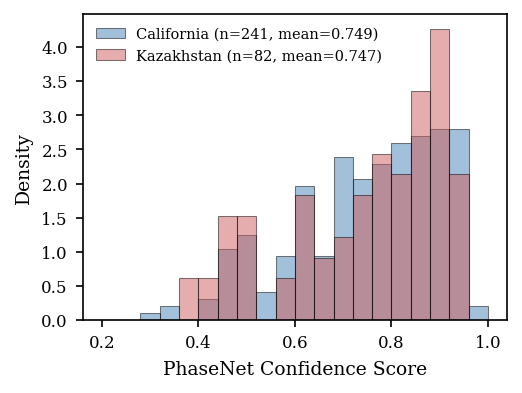

California matched: n=241, mean conf=0.749
Kazakhstan matched: n=82, mean conf=0.747


In [3]:
# Figure 3: Confidence distributions for matched picks
# Reproduces the bottom panel of Cell 76 (Figure 7b) from the main notebook

plt.rcParams['font.family'] = 'serif'

ca_matched = results_df[results_df['matched']]
kz_matched = kz_results_df[kz_results_df['matched']]

ca_conf = ca_matched['confidence'].values
kz_conf = kz_matched['confidence'].values

bins = np.linspace(0.2, 1.0, 21)

fig, ax = plt.subplots(figsize=(3.25, 2.5))

ax.hist(ca_conf, bins=bins, density=True, alpha=0.5,
        color='steelblue', edgecolor='black', linewidth=0.5,
        label=f'California (n={len(ca_conf)}, mean={ca_conf.mean():.3f})')

ax.hist(kz_conf, bins=bins, density=True, alpha=0.5,
        color='indianred', edgecolor='black', linewidth=0.5,
        label=f'Kazakhstan (n={len(kz_conf)}, mean={kz_conf.mean():.3f})')

ax.set_xlabel('PhaseNet Confidence Score')
ax.set_ylabel('Density')
ax.legend(frameon=False, fancybox=False, edgecolor='gray')
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig('figures/fig3_confidence.pdf', bbox_inches='tight')
plt.savefig('figures/fig3_confidence.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'California matched: n={len(ca_conf)}, mean conf={ca_conf.mean():.3f}')
print(f'Kazakhstan matched: n={len(kz_conf)}, mean conf={kz_conf.mean():.3f}')